<a href="https://colab.research.google.com/github/jingxuchen19/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment_4/Econ_5200_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Phase 1: Causal Topology and Multicollinearity Forensics**

**Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
vitals = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")

print(vitals.head())
print(vitals.columns.tolist())

   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0
['Patient_ID', 'Height_cm', 'Weight_kg', 'BMI', 'Systolic_BP', 'Diastolic_BP']


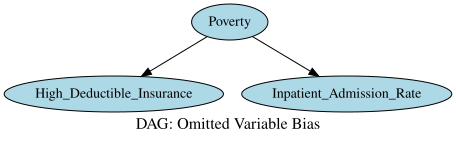

In [26]:
# Draw the DAG (Fork Structure)
import graphviz

dag = graphviz.Digraph()

# Add the three nodes
dag.node("Poverty", "Poverty", style="filled", fillcolor="lightblue")
dag.node("Insurance", "High_Deductible_Insurance", style="filled", fillcolor="lightblue")
dag.node("Admission", "Inpatient_Admission_Rate", style="filled", fillcolor="lightblue")

# Draw arrows from Poverty to both
dag.edge("Poverty", "Insurance")
dag.edge("Poverty", "Admission")

dag.attr(label="DAG: Omitted Variable Bias", fontsize="16")
dag

**Analysis:**

The omitted confounder is Poverty. This is a Fork structure. Poverty is the common cause behind both variables. People with less money tend to pick high-deductible plans because the premiums are lower. And they also tend to have higher admission rates since they skip preventative care and only go to the hospital when things get serious. So the correlation we see between insurance type and admissions isn't causal. it's just both being driven by Poverty. If we run a regression without controlling for this, the coefficient on insurance type will be biased because it picks up the effect of Poverty too.

**Step 1.2: The Variance Inflation Factor (VIF) Audit**

In [27]:
# Step 1.2: VIF Audit
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Pick only the continues features (drop Patient_ID)
features = vitals[["Height_cm", "Weight_kg", "BMI", "Systolic_BP", "Diastolic_BP"]]

# Add a constant column
features_with_const = sm.add_constant(features)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = features_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(features_with_const.values, i)
                    for i in range(features_with_const.shape[1])]

print("VIF before Dropping")
print(vif_data)

VIF before Dropping
        Feature          VIF
0         const  3369.565806
1     Height_cm    28.419446
2     Weight_kg    57.428058
3           BMI    16.981232
4   Systolic_BP     4.219406
5  Diastolic_BP     4.219820


In [28]:
# Drop BMI (most redundant - derived from Height and Weight)
features_clean = vitals[["Height_cm", "Weight_kg", "Systolic_BP", "Diastolic_BP"]]

# Recalculate VIF
features_clean_const = sm.add_constant(features_clean)

vif_after = pd.DataFrame()
vif_after["Feature"] = features_clean_const.columns
vif_after["VIF"] = [variance_inflation_factor(features_clean_const.values, i)
                    for i in range(features_clean_const.shape[1])]

print("VIF after dropping BMI")
print(vif_after)

VIF after dropping BMI
        Feature         VIF
0         const  321.090128
1     Height_cm    3.763812
2     Weight_kg    3.763969
3   Systolic_BP    4.219406
4  Diastolic_BP    4.219820


**Phase 2: Visual Forensics and The High-Cardinality Frontier**

**Step 2.1: The Architecture of Missingness**

In [29]:
# Check what's in the telemetry data
print(telemetry.head())
print(telemetry.columns.tolist())
print(telemetry.shape)

   Patient_ID  High_Deductible_Insurance_Plan  Inpatient_Admission_Rate  \
0        1000                               1                     0.341   
1        1001                               0                     0.213   
2        1002                               0                     0.166   
3        1003                               1                     0.143   
4        1004                               0                     0.219   

   Continuous_Heart_Rate Primary_Diagnosis_Code  Clinic_Capacity_Percentage  \
0                   76.9                J86.381                        0.63   
1                   79.6                M29.789                        0.71   
2                   92.3                E49.618                        0.76   
3                   79.3                E66.244                        0.52   
4                   75.9                J45.553                        0.65   

   Time_of_Day_Index  Procedure_Cost_USD  
0               19.4           

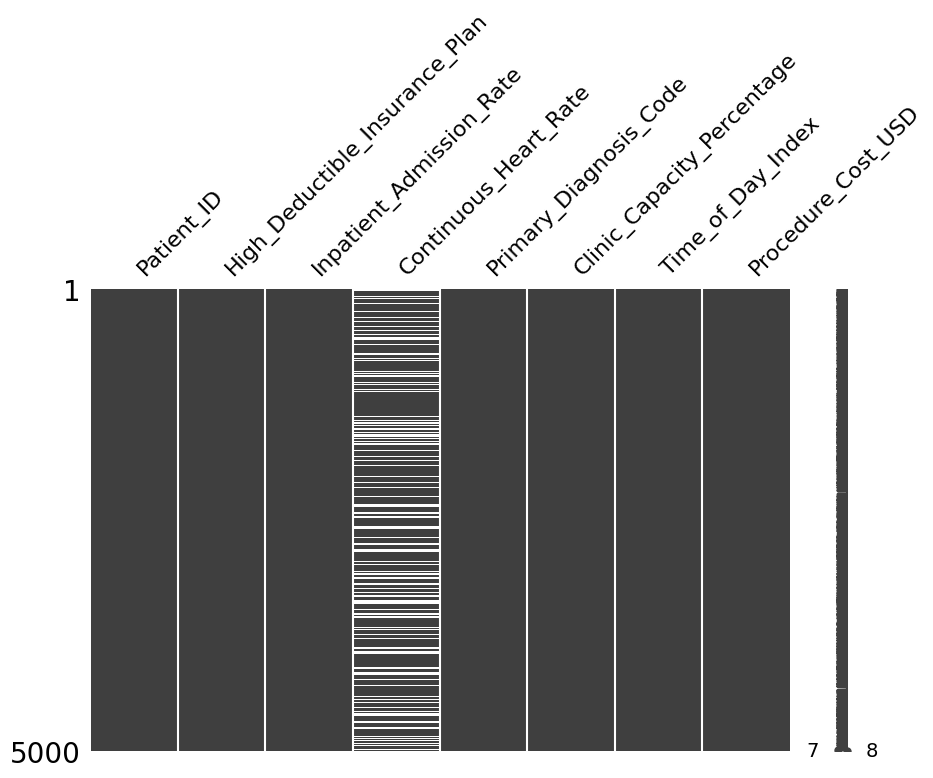

In [30]:
# Missingness Matrix
import missingno as msno

msno.matrix(telemetry, figsize=(10, 6))
plt.show()

**Analysis:**

The missingness matrix shows that Continuous_Heart_Rate has a lot of gaps, while the other columns are fully complete. The reason for the missing data is that low-income patients can't afford the data plan costs for streaming. So this is MNAR (Missing Not At Random). That is, whether the data is missing depends on patient income, and that isn't recorded in the dataset. Mean imputation would be a bad choice here. Because the patients with missing heart rate data are systematically different from those with complete data. Filling in their values with the overall average would hide that difference and bias the model.

**Step 2.2: The Dummy Variable Trap**

If we one-hot encode Primary_Diagnosis_Code using pd.get_dummies(), we'd get 850 binary columns. The problem is that for every row, exactly one dummy equals 1 and the rest are 0, so they always sum to 1. OLS also adds an intercept column that's all 1s. So the intercept is just a perfect linear combination of the 850 dummies. This makes the design matrix X singular, meaning X'X can't be inverted. Since the OLS formula needs (X'X)⁻¹X'y, the whole estimation breaks down. That's the dummy variable trap.

**Step 2.3: Target Encoding Implementation**

In [31]:
!pip install category_encoders

In [32]:
# Target Encoding for Primary_Diagnosis_Code
import category_encoders as ce

encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])
telemetry["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    telemetry["Primary_Diagnosis_Code"], telemetry["Procedure_Cost_USD"])

print(telemetry[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head())

  Primary_Diagnosis_Code  Target_Encoded_Diagnosis
0                J86.381               1707.697108
1                M29.789               1792.303198
2                E49.618               1730.334968
3                E66.244               1725.060944
4                J45.553               1801.821085


**Phase 3: Architecting the Prediction Engine**

**Step 3.1: OLS Optimization via Patsy Formulas**

In [33]:
# Merge data and run OLS
import statsmodels.formula.api as smf

df = pd.merge(vitals, telemetry, on="Patient_ID")
df = df.drop(columns=["BMI"])

df["Target_Encoded_Diagnosis"] = telemetry["Target_Encoded_Diagnosis"]

# Define the OLS formula and fit the model
formula = "Procedure_Cost_USD ~ Target_Encoded_Diagnosis + Clinic_Capacity_Percentage + Time_of_Day_Index + Height_cm + Weight_kg + Systolic_BP + Diastolic_BP"
model = smf.ols(formula, data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        05:23:57   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

**Step 3.2: Financial Loss Quantification (RMSE)**

In [34]:
# Calculate RMSE
from statsmodels.tools.eval_measures import rmse

# Get predicted values and actual values
predicted = model.predict()
actual = df["Procedure_Cost_USD"]

# Calculate RMSE
rmse_value = rmse(actual, predicted)
print("RMSE:", rmse_value)

RMSE: 334.80215211463116


**Analysis:**

The RMSE is about 334.80 USD, so on average the model is off by around 335 dollars. If a typical MRI costs 1,200 USD and the error is 450 USD, that means a patient could be quoted anywhere from 750 to 1,650 for the same procedure. That's a huge range. In a real hospital, this could mean patients getting overcharged or the hospital losing money. There's also regulatory risk. Healthcare pricing is heavily scrutinized, and big unpredictable swings in cost could lead to legal trouble or patients losing trust.

**Step 3.3: Residual Diagnostics for Heteroscedasticity**

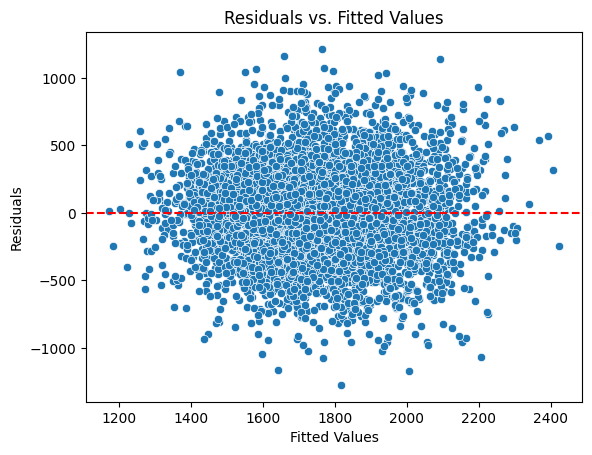

In [35]:
# Residual Diagnostics
fitted = model.fittedvalues
residuals = model.resid

sns.scatterplot(x=fitted, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.show()

**Analysis:**

From the scatter plot, the residuals seem to spread out more as the fitted values get larger. The right side of the plot is wider than the left. This suggests heteroscedasticity, meaning the model's errors aren't constant across different price levels. Basically, the model is less accurate when predicting expensive procedures. That is exactly where you'd want it to be most reliable for a pricing algorithm.

**Phase 4: AI Context Engineering (The P.R.I.M.E. Framework)**

**Task 4.1: Lagrange Multiplier Test for Heteroscedasticity**

**My P.R.I.M.E. Prompt:**

**Persona:** You are a senior econometrician with expertise in regression diagnostics.

**Role:** Your role is to help me test whether my OLS model violates the homoscedasticity assumption.

**Instructions:** Write a Python script that performs White's Lagrange Multiplier Test for heteroscedasticity using the `het_white` function from `statsmodels.stats.diagnostic`. The test should be applied to the residuals and the exogenous variables from my fitted OLS model (stored in a variable called `model`). Print the LM test statistic and its p-value.

**Meaning:** This test matters because if heteroscedasticity is present, the standard errors from OLS are unreliable, which means our confidence intervals and hypothesis tests could be wrong. We need to confirm whether this is an issue before deploying the pricing algorithm.

**Evaluation:** The output should clearly show the LM statistic and p-value. If the p-value is below 0.05, we reject the null hypothesis of homoscedasticity and confirm that heteroscedasticity is present in the model.

In [36]:
# Step 4.1: White's LM Test for Heteroscedasticity (AI-generated code)
from statsmodels.stats.diagnostic import het_white

# Run White's test using residuals and exogenous variables from the model
white_test = het_white(model.resid, model.model.exog)

# Extract results
lm_stat = white_test[0]
lm_pvalue = white_test[1]

print("LM Statistic:", lm_stat)
print("P-value:", lm_pvalue)

LM Statistic: 186.4677397066078
P-value: 1.4380291432915676e-22


**Conclusion:**

The p-value is about 1.44e-22, which is basically 0 — way below 0.05. So we reject the null hypothesis of homoscedasticity. This confirms there is heteroscedasticity in the model, which lines up with what we saw in the residual plot from Step 3.3. The OLS standard errors are unreliable, so the pricing algorithm shouldn't be deployed as-is without fixing this issue first.